# Dataset : Kickstarter Campaigns
Kickstarter is an online crowdfunding platform aimed at helping people get their ideas funded while building a community of fans to support their ideas.

The Kickstarter Campaigns dataset is a structured collection of information about crowdfunding projects launched on the Kickstarter platform. Each row represents a single campaign, and the dataset captures both descriptive details and performance outcomes. It’s widely used in business analytics and machine learning because it combines categorical, textual, and numerical features.



## Import Libraries

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency

## Dataset Split

In [2]:
possible_paths = [
    Path("../data/raw/kickstarter_data_with_features.csv"),
    Path("data/raw/kickstarter_data_with_features.csv"),
    Path("/content/kickstarter_data_with_features.csv"),
    Path("/kickstarter_data_with_features.csv"),
    Path("../data/kickstarter_data_with_features.csv")
]

for dataset_path in possible_paths:
    if dataset_path.exists():
        df = pd.read_csv(dataset_path)
        print(f"Loaded dataset from: {dataset_path}")
        break
else:
    raise FileNotFoundError("Dataset file was not found in the expected locations.")

print("Shape: ",df.shape)
display(df.sample(5))

Loaded dataset from: ..\data\kickstarter_data_with_features.csv
Shape:  (20632, 60)


C:\Users\bshni\AppData\Local\Temp\ipykernel_20368\396192296.py:11: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)


,Unnamed: 0,id,photo,name,blurb,goal,pledged,state,slug,disable_communication,...,created_at_day,created_at_yr,created_at_hr,launched_at_month,launched_at_day,launched_at_yr,launched_at_hr,create_to_launch,launch_to_deadline,launch_to_state_change
16861,16861,69495755,"{""small"":""https://ksr-ugc.imgix.net/assets/012...",Bring Back Walt Disney's Midget Autopia Ride,In 1966 Walt Disney donated the much loved Mid...,500000.0,21740.0,failed,bring-back-walt-disneys-midget-autopia-ride,False,...,18,2015,10,7,31,2015,7,12 days 21:41:05.000000000,60 days 00:00:00.000000000,NaN
12179,12179,1743139692,"{""small"":""https://ksr-ugc.imgix.net/assets/012...",E-Bot: Hack Learning w/ Arduino Robotics And C...,E-Bot is an awesome open-source Arduino wirele...,100000.0,105.0,failed,opensource-educational-swarm-robots,False,...,23,2015,13,3,2,2015,19,7 days 05:28:12.000000000,30 days 00:00:00.000000000,NaN
6594,6594,104087453,"{""small"":""https://ksr-ugc.imgix.net/assets/011...",BoardSeat - Who's On Your Board?,Because you don’t have all the answers. And ev...,175000.0,58369.0,failed,boardseat-whos-on-your-board,False,...,15,2014,13,11,17,2015,5,397 days 16:30:48.000000000,25 days 17:14:13.000000000,NaN
18951,18951,2077444678,"{""small"":""https://ksr-ugc.imgix.net/assets/014...",Capacitor sets for vintage Yamaha HiFi devices.,Complete electrolytic capacitor sets to bring ...,650.0,21.0,failed,capacitor-sets-for-vintage-yamaha-hifi-devices,False,...,13,2016,9,10,15,2016,4,1 days 18:41:51.000000000,60 days 00:00:00.000000000,NaN
5507,5507,1192979081,"{""small"":""https://ksr-ugc.imgix.net/assets/012...",CarFae,INNOVATING THE WAY WE FIND AUTOMOBILE SERVICES.,5000.0,1285.0,failed,carfae,False,...,18,2015,12,8,20,2015,11,1 days 23:20:11.000000000,36 days 10:19:18.000000000,NaN


In [3]:
df = df[df['state'] != 'live']

In [4]:
# Target (boolean: success vs not-success)
y = df['state'].apply(lambda x: 1 if x == 'successful' else 0)

# Features (drop target column)
X = df.drop('state', axis=1)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Shape: ",X_train.shape)

Shape:  (16099, 59)


## Dataset Overview

In [6]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16099 entries, 12395 to 12971
Data columns (total 59 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                16099 non-null  int64  
 1   id                        16099 non-null  int64  
 2   photo                     16099 non-null  object 
 3   name                      16099 non-null  object 
 4   blurb                     16094 non-null  object 
 5   goal                      16099 non-null  float64
 6   pledged                   16099 non-null  float64
 7   slug                      16099 non-null  object 
 8   disable_communication     16099 non-null  bool   
 9   country                   16099 non-null  object 
 10  currency                  16099 non-null  object 
 11  currency_symbol           16099 non-null  object 
 12  currency_trailing_code    16099 non-null  bool   
 13  deadline                  16099 non-null  object 
 14  state_c

In [7]:
display(X_train.describe())

,Unnamed: 0,id,goal,pledged,backers_count,static_usd_rate,usd_pledged,name_len,name_len_clean,blurb_len,...,state_changed_at_yr,state_changed_at_hr,created_at_month,created_at_day,created_at_yr,created_at_hr,launched_at_month,launched_at_day,launched_at_yr,launched_at_hr
count,16099.000000,1.609900e+04,1.609900e+04,1.609900e+04,16099.000000,16099.000000,1.609900e+04,16094.000000,16094.000000,16094.000000,...,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000
mean,10246.896515,1.071304e+09,9.500371e+04,2.168050e+04,188.474998,1.041232,2.127517e+04,5.947185,5.299428,18.991301,...,2014.764085,12.872042,6.520778,15.499286,2014.561774,12.721411,6.672961,15.333064,2014.687993,12.431393
std,5938.624078,6.155893e+08,1.261388e+06,1.262645e+05,1316.271464,0.228508,1.206762e+05,2.826571,2.419345,4.639404,...,1.235325,6.057108,3.305366,8.787213,1.251197,5.971916,3.333543,8.773351,1.226995,5.585826
min,0.000000,1.645550e+05,1.000000e+00,0.000000e+00,0.000000,0.046558,0.000000e+00,1.000000,1.000000,1.000000,...,2009.000000,0.000000,1.000000,1.000000,2009.000000,0.000000,1.000000,1.000000,2009.000000,0.000000
25%,5123.500000,5.437075e+08,4.000000e+03,2.500000e+01,2.000000,1.000000,2.500000e+01,4.000000,3.000000,17.000000,...,2014.000000,9.000000,4.000000,8.000000,2014.000000,9.000000,4.000000,8.000000,2014.000000,9.000000
50%,10246.000000,1.070884e+09,1.350000e+04,7.050000e+02,12.000000,1.000000,7.260000e+02,6.000000,5.000000,20.000000,...,2015.000000,13.000000,7.000000,15.000000,2015.000000,13.000000,7.000000,15.000000,2015.000000,12.000000
75%,15334.500000,1.602768e+09,5.000000e+04,6.031500e+03,64.000000,1.000000,6.088500e+03,8.000000,7.000000,22.000000,...,2016.000000,17.000000,9.000000,23.000000,2015.000000,17.000000,10.000000,23.000000,2016.000000,16.000000
max,20631.000000,2.147017e+09,1.000000e+08,6.225355e+06,105857.000000,1.715913,6.225355e+06,16.000000,14.000000,35.000000,...,2017.000000,23.000000,12.000000,31.000000,2017.000000,23.000000,12.000000,31.000000,2017.000000,23.000000


## Missing Value Analysis

In [8]:
X_train.isnull().sum()

Unnamed: 0                      0
id                              0
photo                           0
name                            0
blurb                           5
goal                            0
pledged                         0
slug                            0
disable_communication           0
country                         0
currency                        0
currency_symbol                 0
currency_trailing_code          0
deadline                        0
state_changed_at                0
created_at                      0
launched_at                     0
staff_pick                      0
backers_count                   0
static_usd_rate                 0
usd_pledged                     0
creator                         0
location                       34
category                     1472
profile                         0
spotlight                       0
urls                            0
source_url                      0
friends                     16087
is_starred    

friends / is_starred / is_backing / permissions: These are mostly empty (personalized views) as they relate to a specific logged-in user's social connections.

## Duplicates Check

In [9]:
X_train.duplicated().sum()

0

In [10]:
X_train.nunique()

Unnamed: 0                  16099
id                          16099
photo                       16099
name                        16083
blurb                       15992
goal                         1030
pledged                      7232
slug                        16099
disable_communication           2
country                        21
currency                       13
currency_symbol                 5
currency_trailing_code          2
deadline                    15928
state_changed_at            15962
created_at                  16097
launched_at                 16097
staff_pick                      2
backers_count                1312
static_usd_rate              2668
usd_pledged                  9815
creator                     16035
location                     4417
category                       24
profile                     16099
spotlight                       2
urls                        16099
source_url                     33
friends                         1
is_starred    

In [11]:
X_train["category"].nunique()

24

## Data type issues (Suggestions)

In [12]:
# Suggest Data types changes
# Categorical Data
categorical_cols = X_train.columns[X_train.nunique() <= 35].tolist()
# Datetime columns
date_cols = ["deadline", "state_changed_at", "created_at", "launched_at"]

## Outliers Detection

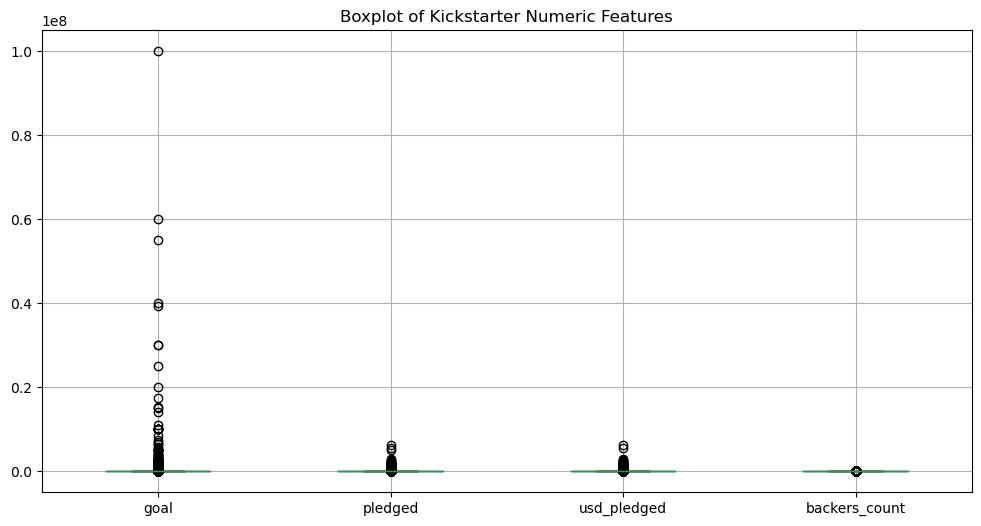

In [13]:
# Numeric columns to check
numeric_cols = ['goal', 'pledged', 'usd_pledged', 'backers_count']

# Boxplots only on training set
plt.figure(figsize=(12, 6))
X_train[numeric_cols].boxplot()
plt.title("Boxplot of Kickstarter Numeric Features")
plt.show()


Goal -> Most campaigns set small targets, but a few ask for millions, creating extreme outliers.

Pledged -> Typical campaigns raise modest amounts; blockbuster successes stand out as high outliers.

USD_Pledged -> Mirrors pledged values, normalized to USD; again, a few huge campaigns skew the scale.

Backers_Count -> Most projects have few supporters, but viral hits with tens of thousands of backers appear as outliers.

In short: all four features are highly skewed , most campaigns cluster at low values, while rare mega-projects dominate the upper end.

In [14]:
# Combine X_train and y_train back for grouped plotting
train_df = X_train.copy()
train_df["state_binary"] = y_train
train_df["state"] = y_train.replace({1: "successful", 0: "failed"})

## Target Analysis

In [15]:
# Define colors for states
colors = {
    "successful": "green",
    "failed": "red",
}

state
failed        11285
successful     4814
Name: count, dtype: int64

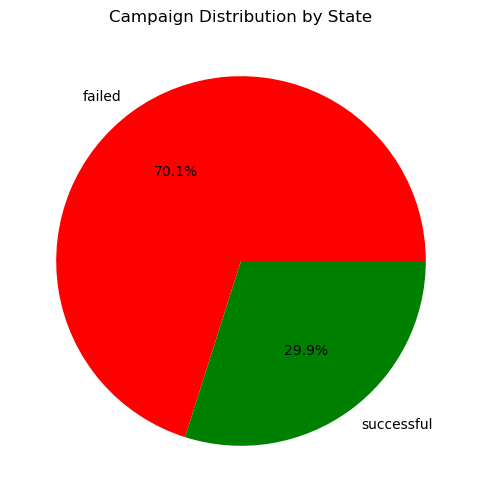

In [16]:
state_counts = train_df['state'].value_counts()

display(state_counts)

state_counts.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6),colors=[colors.get(state, "grey") for state in state_counts.index])
plt.title("Campaign Distribution by State")
plt.ylabel("")
plt.show()


The dataset reveals a strong imbalance in campaign outcomes, with failed projects making up the majority at around 70%, while successful ones account for only about 30%. This skew highlights that failure is the dominant result across categories, timing, and durations, and it underscores the challenge of achieving success in such a competitive environment. For modeling, this imbalance means predictive algorithms may lean toward the majority “failed” class, so corrective techniques like resampling, class weighting, or balanced metrics are necessary to ensure fair performance across all outcomes.

## Categorical Feature analysis

In [17]:
cat_cols = train_df.select_dtypes(include=['object', 'category']).columns
cat_cols

Index(['photo', 'name', 'blurb', 'slug', 'country', 'currency',
       'currency_symbol', 'deadline', 'state_changed_at', 'created_at',
       'launched_at', 'creator', 'location', 'category', 'profile', 'urls',
       'source_url', 'friends', 'is_starred', 'is_backing', 'permissions',
       'deadline_weekday', 'state_changed_at_weekday', 'created_at_weekday',
       'launched_at_weekday', 'create_to_launch', 'launch_to_deadline',
       'launch_to_state_change', 'state'],
      dtype='object')

In [18]:
for col in cat_cols:
    print(col)
    print(train_df[col].value_counts())
    print("-"*30)

photo
photo
{"small":"https://ksr-ugc.imgix.net/assets/011/997/157/69f08ccc461125e2dfd8779c4cd24b02_original.png?w=160&h=90&fit=fill&bg=000000&v=1463722601&auto=format&q=92&s=7de7ec4b4d8ede8505e9964fd79ad834","thumb":"https://ksr-ugc.imgix.net/assets/011/997/157/69f08ccc461125e2dfd8779c4cd24b02_original.png?w=40&h=22&fit=fill&bg=000000&v=1463722601&auto=format&q=92&s=ed30164e586694e17328df76bb0656c7","1024x576":"https://ksr-ugc.imgix.net/assets/011/997/157/69f08ccc461125e2dfd8779c4cd24b02_original.png?w=1024&h=576&fit=fill&bg=000000&v=1463722601&auto=format&q=92&s=a54300a9eac9b7389622038160b914a5","med":"https://ksr-ugc.imgix.net/assets/011/997/157/69f08ccc461125e2dfd8779c4cd24b02_original.png?w=266&h=150&fit=fill&bg=000000&v=1463722601&auto=format&q=92&s=3132247e2e9c7e4a0a9ee8c9e73b9c5e","key":"assets/011/997/157/69f08ccc461125e2dfd8779c4cd24b02_original.png","1536x864":"https://ksr-ugc.imgix.net/assets/011/997/157/69f08ccc461125e2dfd8779c4cd24b02_original.png?w=1536&h=864&fit=fill&bg

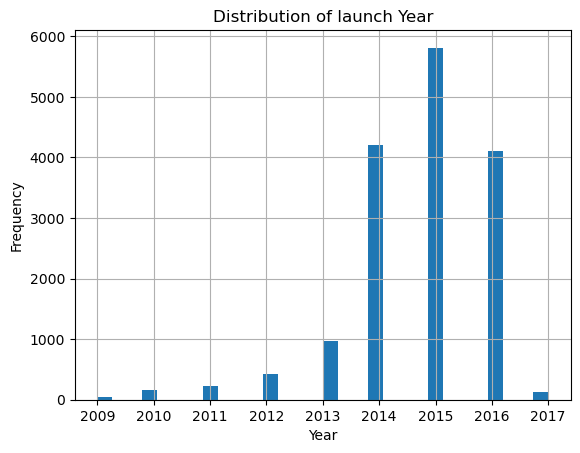

In [19]:
train_df['launched_at_yr'].hist(bins=30)
plt.title('Distribution of launch Year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

Most campaigns in the dataset were launched during the mid‑2010s, especially 2015, which represents the peak period of activity.

<Axes: xlabel='country'>

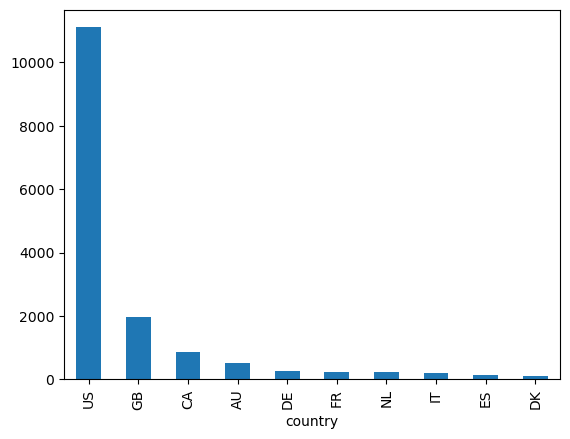

In [20]:
# Top Countries by Campaign Count: where most campaigns originate
train_df["country"].value_counts().head(10).plot(kind="bar")

United States (US): Dominates with the highest number of campaigns by far.

United Kingdom (GB) & Canada (CA) : Next largest contributors, but far behind the US.

Australia (AU), Germany (DE), Netherlands (NL), France (FR), Italy (IT), Spain (ES), Denmark (DK) : Moderate contributors, each with significantly fewer campaigns compared to the US.

Focus outreach and analysis on the US market first, while also tailoring strategies for other major English‑speaking countries to maximize campaign visibility

## Numerical Features Distribution

In [21]:
# Drop the unwanted column from training set
train_df = train_df.drop('Unnamed: 0', axis=1)

In [22]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

In [23]:
train_df[num_cols].describe()

,id,goal,pledged,backers_count,static_usd_rate,usd_pledged,name_len,name_len_clean,blurb_len,blurb_len_clean,...,state_changed_at_hr,created_at_month,created_at_day,created_at_yr,created_at_hr,launched_at_month,launched_at_day,launched_at_yr,launched_at_hr,state_binary
count,1.609900e+04,1.609900e+04,1.609900e+04,16099.000000,16099.000000,1.609900e+04,16094.000000,16094.000000,16094.000000,16094.000000,...,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000,16099.000000
mean,1.071304e+09,9.500371e+04,2.168050e+04,188.474998,1.041232,2.127517e+04,5.947185,5.299428,18.991301,13.074748,...,12.872042,6.520778,15.499286,2014.561774,12.721411,6.672961,15.333064,2014.687993,12.431393,0.299025
std,6.155893e+08,1.261388e+06,1.262645e+05,1316.271464,0.228508,1.206762e+05,2.826571,2.419345,4.639404,3.283769,...,6.057108,3.305366,8.787213,1.251197,5.971916,3.333543,8.773351,1.226995,5.585826,0.457845
min,1.645550e+05,1.000000e+00,0.000000e+00,0.000000,0.046558,0.000000e+00,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,2009.000000,0.000000,1.000000,1.000000,2009.000000,0.000000,0.000000
25%,5.437075e+08,4.000000e+03,2.500000e+01,2.000000,1.000000,2.500000e+01,4.000000,3.000000,17.000000,11.000000,...,9.000000,4.000000,8.000000,2014.000000,9.000000,4.000000,8.000000,2014.000000,9.000000,0.000000
50%,1.070884e+09,1.350000e+04,7.050000e+02,12.000000,1.000000,7.260000e+02,6.000000,5.000000,20.000000,13.000000,...,13.000000,7.000000,15.000000,2015.000000,13.000000,7.000000,15.000000,2015.000000,12.000000,0.000000
75%,1.602768e+09,5.000000e+04,6.031500e+03,64.000000,1.000000,6.088500e+03,8.000000,7.000000,22.000000,15.000000,...,17.000000,9.000000,23.000000,2015.000000,17.000000,10.000000,23.000000,2016.000000,16.000000,1.000000
max,2.147017e+09,1.000000e+08,6.225355e+06,105857.000000,1.715913,6.225355e+06,16.000000,14.000000,35.000000,28.000000,...,23.000000,12.000000,31.000000,2017.000000,23.000000,12.000000,31.000000,2017.000000,23.000000,1.000000


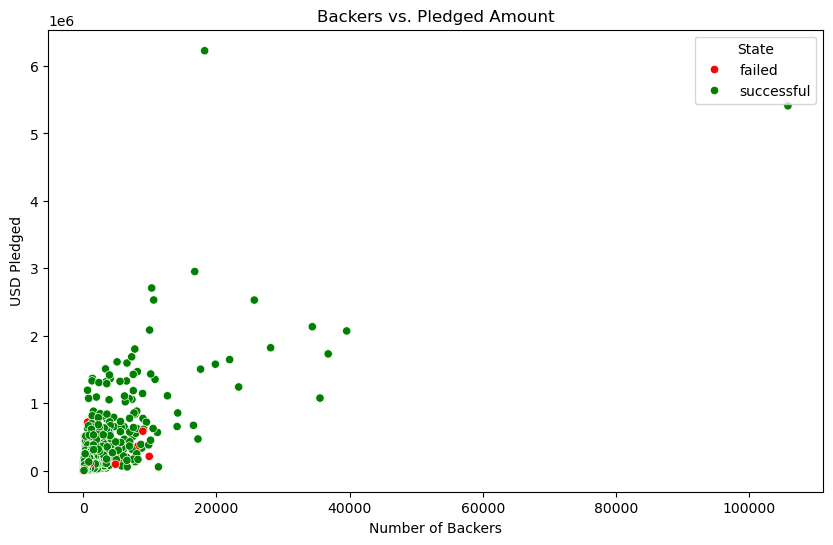

In [24]:
# Backers vs. Pledged Amount :
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="backers_count",
    y="usd_pledged",
    hue="state",
    data=train_df,
    palette=colors
)

plt.title("Backers vs. Pledged Amount")
plt.xlabel("Number of Backers")
plt.ylabel("USD Pledged")
plt.legend(title="State")
plt.show()

There’s a clear positive relationship between the number of backers and the pledged amount: campaigns with more backers consistently raise more money.

Successful campaigns cluster toward the upper‑right, showing both higher pledged amounts and larger backer counts.

Failed campaigns remain concentrated in the lower‑left, with fewer backers and smaller pledged totals.

There’s a clear positive relationship: more backers usually means more money pledged.

Creators should focus on building a strong supporter base. Campaigns with many engaged backers are far more likely to succeed and raise significant funds.

## Features Correlation

                              id      goal   pledged  backers_count  \
id                      1.000000  0.005910  0.007632      -0.000407   
goal                    0.005910  1.000000  0.012411       0.005609   
pledged                 0.007632  0.012411  1.000000       0.723243   
backers_count          -0.000407  0.005609  0.723243       1.000000   
static_usd_rate        -0.006020 -0.034799 -0.045034      -0.004113   
usd_pledged             0.003566  0.012420  0.951549       0.757433   
name_len                0.001480 -0.014119  0.079559       0.055144   
name_len_clean          0.002336 -0.012836  0.083705       0.056786   
blurb_len              -0.000289 -0.009458  0.001756       0.001061   
blurb_len_clean         0.002321 -0.010075  0.015644       0.011822   
deadline_month         -0.002683  0.001304  0.013112       0.008715   
deadline_day           -0.001392 -0.014540 -0.011364      -0.012545   
deadline_yr             0.002575  0.011478  0.004297      -0.015641   
deadli

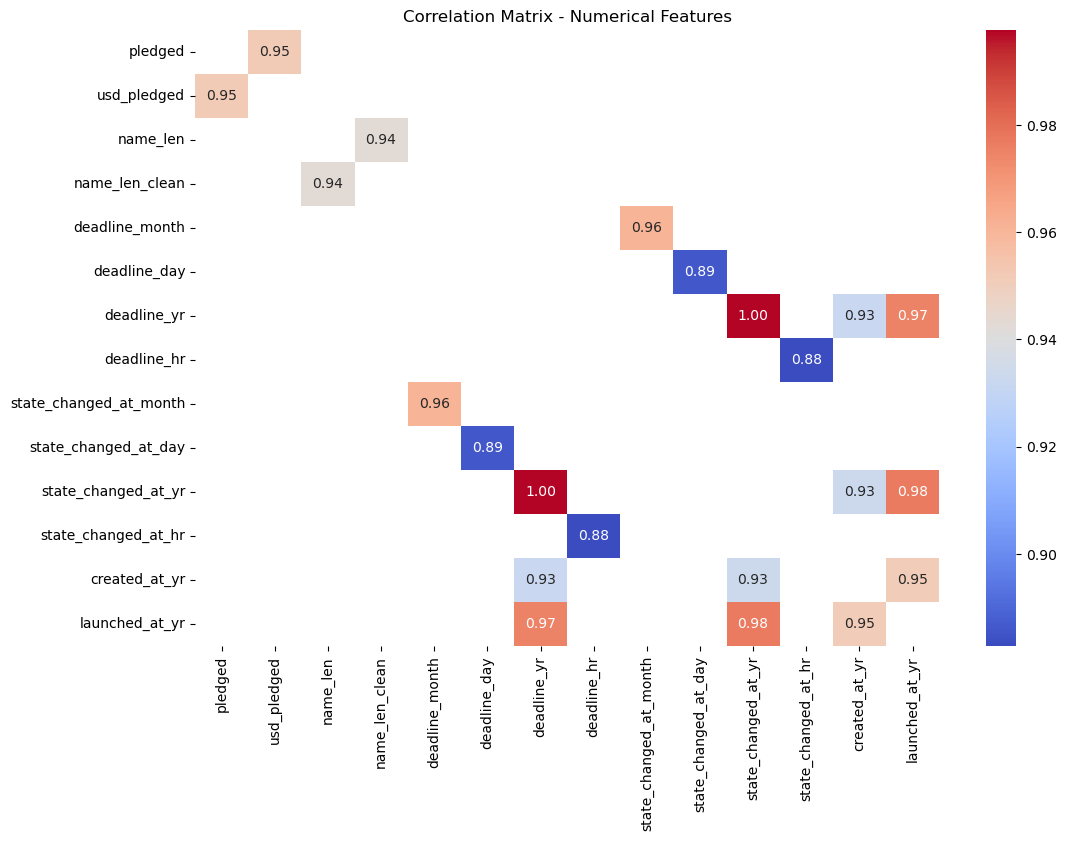

In [25]:
# Select numeric columns (including the new state_binary)
numeric_df = train_df.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()
# Print the correlation matrix
print(corr_matrix)


high_corr = corr_matrix[(corr_matrix.abs() > 0.8) & (corr_matrix.abs() < 1)]
filtered_corr = high_corr.dropna(how='all').dropna(axis=1, how='all')

# Heatmap for all numerical correlations
plt.figure(figsize=(12,8))
sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Numerical Features")
plt.show()

pledged and usd_pledged → very strong correlation (~0.95).

name_len and name_len_clean → highly correlated (~0.94).

deadline_month, deadline_day, deadline_yr, deadline_hr → strongly correlated cluster.

state_changed_at_month, state_changed_at_day, state_changed_at_yr, state_changed_at_hr → tightly linked cluster.

created_at_yr and launched_at_yr → highly correlated (close in time).

## Feature Relatonship with target

Correlations with target (state_binary):
usd_pledged               0.225989
pledged                   0.218313
backers_count             0.184233
name_len_clean            0.138805
name_len                  0.137421
blurb_len_clean           0.065427
static_usd_rate           0.057790
blurb_len                 0.024304
state_changed_at_month    0.012413
deadline_month            0.012162
state_changed_at_hr       0.008131
created_at_hr             0.002525
created_at_day            0.002431
deadline_hr               0.001857
state_changed_at_day     -0.006059
deadline_day             -0.007423
launched_at_month        -0.007678
launched_at_day          -0.008047
created_at_month         -0.011084
id                       -0.013474
goal                     -0.038165
launched_at_yr           -0.055289
created_at_yr            -0.057622
launched_at_hr           -0.057851
state_changed_at_yr      -0.058574
deadline_yr              -0.062189
Name: state_binary, dtype: float64


C:\Users\bshni\AppData\Local\Temp\ipykernel_20368\3095109171.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_sorted.values, y=corr_sorted.index, palette="coolwarm")


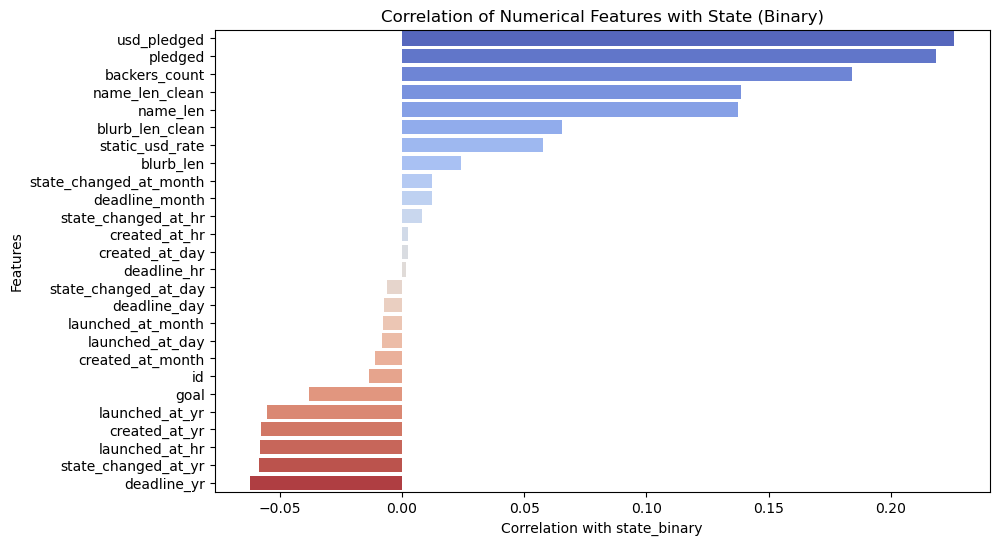

In [26]:
# Extract correlations with target only
corr_with_target = corr_matrix['state_binary'].drop('state_binary')

print("Correlations with target (state_binary):")
print(corr_with_target.sort_values(ascending=False))

corr_sorted = corr_with_target.sort_values(ascending=False)
# Visualize as bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=corr_sorted.values, y=corr_sorted.index, palette="coolwarm")
plt.title("Correlation of Numerical Features with State (Binary)")
plt.xlabel("Correlation with state_binary")
plt.ylabel("Features")
plt.show()

usd_pledged and pledged show the strongest positive correlation with success. Higher funding directly drives successful outcomes.

backers_count is also strongly correlated, meaning campaigns with more supporters are more likely to succeed.

name_len_clean and name_len have moderate positive correlations, suggesting that longer campaign names may slightly improve success, possibly due to clarity or detail.

duration_days shows a weaker positive correlation, hinting that campaign length matters but is not the strongest driver.

Text‑related features such as blurb_len_clean and blurb_len have small correlations, meaning description length alone does not guarantee success.

Time‑related features (deadline, created_at, launched_at, state_changed_at) show correlations close to zero or slightly negative, indicating that raw date components do not strongly influence success.

goal has a weak negative correlation, suggesting that higher funding goals slightly reduce the chance of success.

,feature,chi2,p_value
28,state,16094.229565,0.000000e+00
13,category,2066.507405,0.000000e+00
16,source_url,2382.847173,0.000000e+00
26,launch_to_deadline,5182.948297,1.152637e-41
4,country,248.907344,1.897036e-41
5,currency,224.039362,3.446718e-41
6,currency_symbol,137.476466,9.791192e-29
24,launched_at_weekday,58.827352,7.787175e-11
12,location,4999.723902,1.231303e-09
21,deadline_weekday,21.661147,1.394490e-03


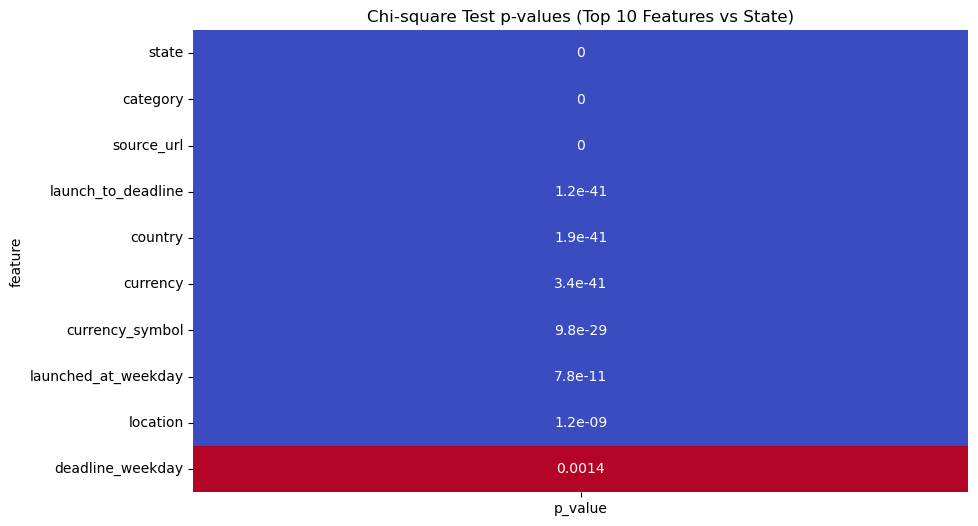

In [27]:
results = []

for col in cat_cols:
    table = pd.crosstab(train_df['state'], train_df[col])
    chi2, p, dof, expected = chi2_contingency(table)
    results.append({'feature': col, 'chi2': chi2, 'p_value': p})

chi_results = pd.DataFrame(results).sort_values(by='p_value')

display(chi_results)

# Take top 10 most significant features
top10 = chi_results.head(10).set_index('feature')

# Heatmap of p-values for top 10
plt.figure(figsize=(10,6))
sns.heatmap(top10[['p_value']], annot=True, cmap='coolwarm', cbar=False)
plt.title("Chi-square Test p-values (Top 10 Features vs State)")
plt.show()

Category, country, and currency are critical categorical drivers of campaign success and should be prioritized in modeling.

Launch‑to‑deadline duration is highly significant, reinforcing the importance of campaign timing.

Location and weekday features add signal but are secondary compared to category and funding context.

Deadline weekday is the least significant among the top predictors, suggesting that the day of deadline matters less than other categorical factors.

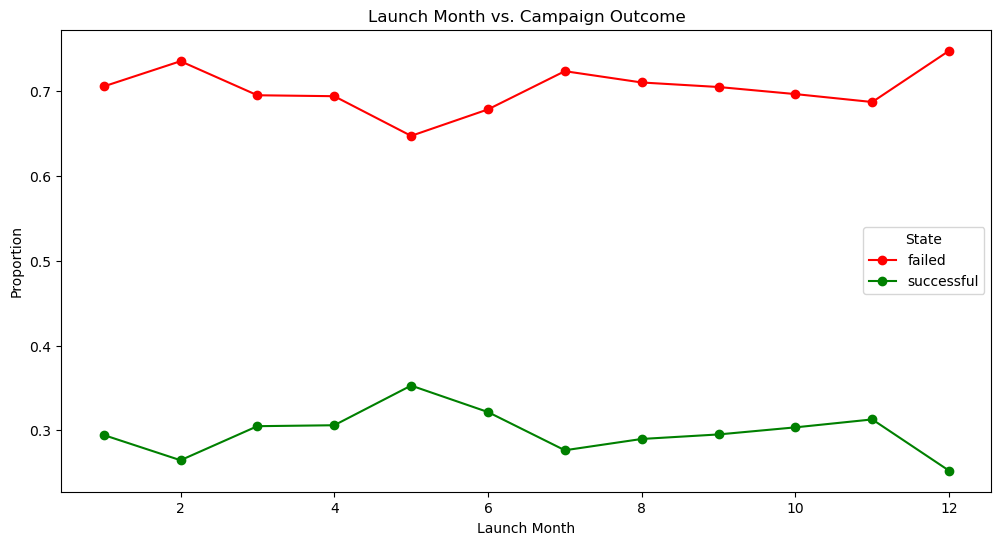

In [28]:
# Group by launch month and state on training set
month_data = train_df.groupby("launched_at_month")["state"].value_counts(normalize=True).unstack()

# Plot with custom colors
month_data.plot(
    kind="line",
    marker="o",
    figsize=(12,6),
    color=[colors.get(col, "grey") for col in month_data.columns]
)

plt.title("Launch Month vs. Campaign Outcome")
plt.ylabel("Proportion")
plt.xlabel("Launch Month")
plt.legend(title="State")
plt.show()


The success rate peaks in Month 5, meaning campaigns launched in May have the highest probability of success compared to other months.
Across other months, failure remains consistently higher than success, but the seasonal dip in May suggests timing plays a meaningful role in campaign performance.

Creators should launch campaigns in Month 5, when success rates are highest. Since failure is common, combining this with previous recommendations.

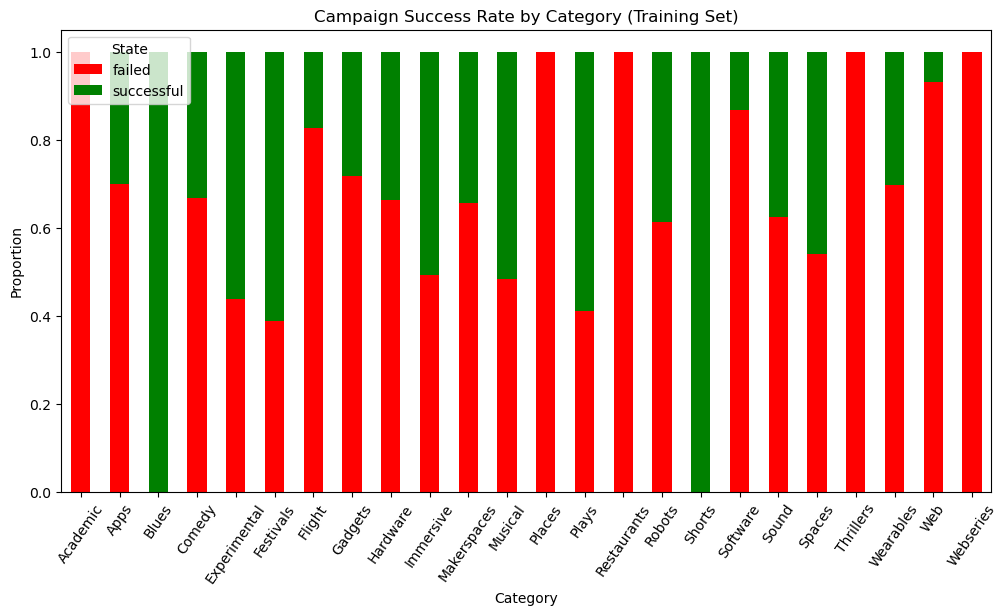

In [29]:
# Group by category and state
train_df.groupby("category")["state"].value_counts(normalize=True).unstack().plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=[colors.get(state, "gray") for state in train_df["state"].unique()]
)

plt.title("Campaign Success Rate by Category (Training Set)")
plt.ylabel("Proportion")
plt.xlabel("Category")
plt.xticks(rotation=55)
plt.legend(title="State")
plt.show()


Most categories show a higher proportion of failed campaigns compared to successful ones.

A few categories (like Comedy, Plays, and Shorts) have relatively better success rates, but still not dominant.

Tech‑heavy categories (e.g., Hardware, Gadgets, Robots) lean strongly toward failure, suggesting higher risk.

Recommendation : Focus on creative/artistic categories if the goal is higher success probability. For tech or product ideas, set realistic goals and clear prototypes to improve chances, since those categories face more failures.

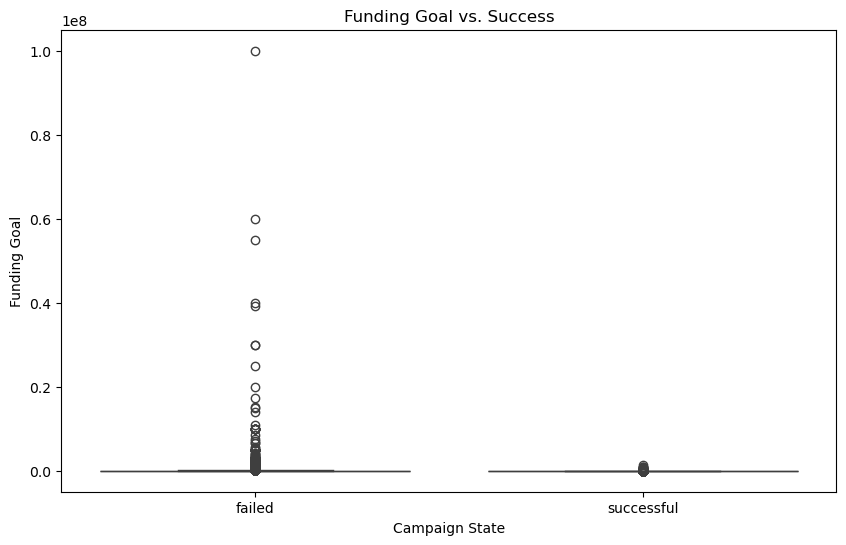

In [30]:
# Funding Goal vs. Success
plt.figure(figsize=(10,6))
sns.boxplot(x="state", y="goal", data=train_df)

plt.title("Funding Goal vs. Success")
plt.ylabel("Funding Goal")
plt.xlabel("Campaign State")
plt.show()


Campaigns with very high funding goals are overwhelmingly clustered in the failed category. This shows that setting ambitious or unrealistic targets often leads to poor outcomes.

Successful campaigns tend to set lower, more achievable goals, with fewer extreme outliers. Their distribution is tighter and closer to modest funding levels.

Creators should set realistic funding goals. Campaigns with smaller, achievable targets are more likely to succeed, while very high goals often end in failure .

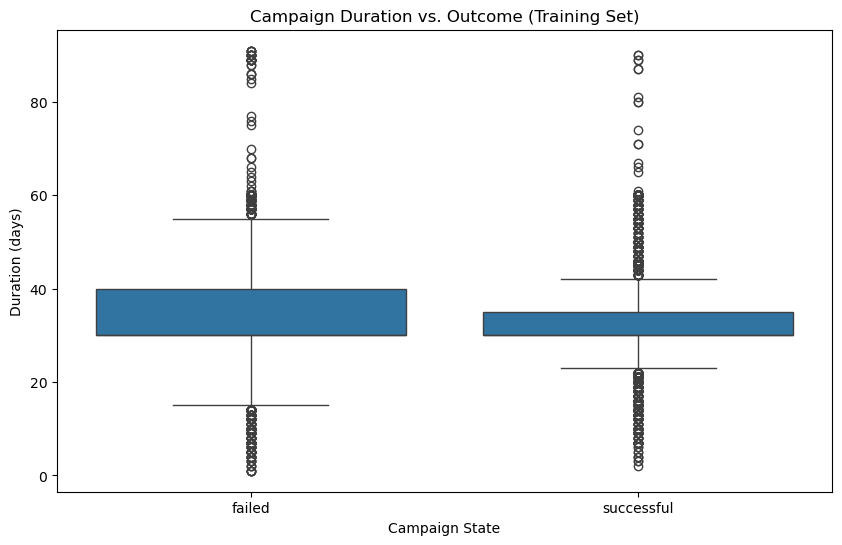

In [31]:
#Campaign Duration vs. Outcome : Shows whether shorter or longer campaign durations are more likely to succeed.
train_df["duration_days"] = (
    pd.to_datetime(train_df["deadline"]) - pd.to_datetime(train_df["launched_at"])
).dt.days

# Boxplot of duration vs. outcome
plt.figure(figsize=(10,6))
sns.boxplot(x="state", y="duration_days", data=train_df)

plt.title("Campaign Duration vs. Outcome (Training Set)")
plt.ylabel("Duration (days)")
plt.xlabel("Campaign State")
plt.show()


Failed campaigns : Durations vary widely, often longer, but still unsuccessful.

Successful campaigns : More consistent, slightly shorter durations.

Outliers : Many extreme cases in both failed and successful, but they don’t represent the norm.

Keep campaign lengths focused around 30 days  longer durations don’t improve success and often lead to failure or cancellation.

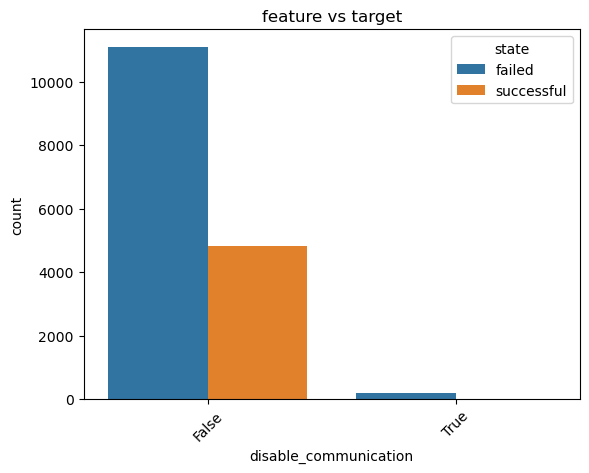

In [32]:
sns.countplot(x='disable_communication', hue='state', data=train_df)
plt.title('feature vs target')
plt.xticks(rotation=45)
plt.show()

disable_communication is a categorical flag that indicates whether a campaign creator has turned off the ability for backers to communicate or leave comments on the project page.

Disabling communication severely reduces the chance of success. Campaigns that prevent backer interaction or updates almost always fail.

Communication is critical for trust and engagement. Backers expect transparency, updates, and interaction; removing this feature undermines credibility.

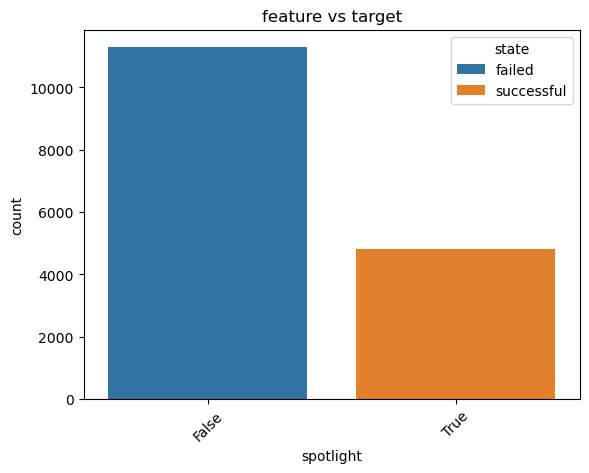

In [33]:
sns.countplot(x='spotlight', hue='state', data=train_df)
plt.title('feature vs target')
plt.xticks(rotation=45)
plt.show()

campaigns placed in the spotlight (platform‑driven visibility flag) are far more likely to succeed, while those not spotlighted tend to fail. This makes spotlight one of the most influential categorical features in your dataset.

## Pipeline-Based Cleaning and Feature Preparation

In this phase, the cleaning and preprocessing steps are implemented using pipelines to ensure a consistent and reproducible workflow.

Instead of manually transforming the training and testing data separately, the pipeline will automatically apply the same steps during training and testing.

The cleaning step removes irrelevant, redundant, or leakage-prone columns, while the preprocessing step handles missing values, scaling, and encoding.

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [35]:
drop_cols = [
    # Index / identifiers
    'Unnamed: 0', 'id',

    # Mostly missing columns
    'friends', 'is_starred', 'is_backing', 'permissions',

    # Links / media columns
    'photo', 'slug', 'urls', 'source_url',

    # Complex / nested columns
    'creator', 'location', 'category', 'profile',

    # Raw text columns
    'name', 'blurb',

    # Data leakage columns
    'pledged', 'usd_pledged', 'backers_count',
    'spotlight', 'state_changed_at', 'launch_to_state_change',

    # Raw datetime columns
    'deadline', 'created_at', 'launched_at',

    # State-change derived columns
    'state_changed_at_weekday',
    'state_changed_at_month',
    'state_changed_at_day',
    'state_changed_at_yr',
    'state_changed_at_hr'
]

Dropping Irrelevant, Redundant, and Leakage Columns

In this step, we remove columns that are not suitable for building a reliable predictive model.

- **Index and identifier columns** (`Unnamed: 0`, `id`) are removed because they do not contain meaningful information for prediction.

- **Columns with excessive missing values** (`friends`, `is_starred`, `is_backing`, `permissions`) are removed due to their high proportion of null values, making them unreliable.

- **Links and media columns** (`photo`, `slug`, `urls`, `source_url`) are removed since they cannot be directly used by machine learning models.

- **Complex nested columns** (`creator`, `location`, `category`, `profile`) are removed because they contain structured or JSON-like data that require advanced processing beyond the scope of this project.

- **Raw text columns** (`name`, `blurb`) are removed because they require NLP techniques such as TF-IDF or embeddings. Instead, we use engineered features like `name_len` and `blurb_len`.

- **Data leakage columns** (`pledged`, `usd_pledged`, `backers_count`, `spotlight`, `state_changed_at`, `launch_to_state_change`) are removed because they include information that becomes available during or after the campaign outcome, which would lead to unrealistic model performance.

- **Raw datetime columns** (`deadline`, `created_at`, `launched_at`) are removed since we already extracted useful components such as day, month, and hour.

- **State-change related features** (`state_changed_at_*`) are removed because they are derived from outcome-related timestamps and introduce data leakage.


In [36]:
import pandas as pd
from sklearn.preprocessing import FunctionTransformer

def clean_data(X):
    X = X.copy()

    # Drop unwanted columns
    X = X.drop(columns=drop_cols)

    # Convert duration columns from text to number of days
    duration_cols = ['create_to_launch', 'launch_to_deadline']

    for col in duration_cols:
        X[col] = pd.to_timedelta(X[col]).dt.total_seconds() / (24 * 60 * 60)

    return X

cleaning_transformer = FunctionTransformer(clean_data, validate=False)

Cleaning Transformer and Duration Conversion

A custom cleaning transformer is implemented using `FunctionTransformer` to perform data cleaning steps within the pipeline.

First, irrelevant, redundant, and leakage-prone columns are removed using a predefined list of columns. This ensures that only valid and meaningful features remain for modeling.

Additionally, the duration columns `create_to_launch` and `launch_to_deadline` were originally stored as text values (e.g., "4 days 02:14:31"), which cannot be processed by numerical preprocessing steps.

To resolve this, these columns are converted into numerical values representing the total number of days using `pandas.to_timedelta`. This allows them to be used in median imputation and scaling.

By including these operations inside the cleaning transformer, the same transformations are automatically and consistently applied to both training and testing data within the pipeline.

In [37]:
numerical_cols = [
    'goal',
    'static_usd_rate',
    'name_len',
    'name_len_clean',
    'blurb_len',
    'blurb_len_clean',
    'deadline_day',
    'deadline_yr',
    'deadline_hr',
    'created_at_day',
    'created_at_yr',
    'created_at_hr',
    'launched_at_day',
    'launched_at_yr',
    'launched_at_hr',
    'create_to_launch',
    'launch_to_deadline'
]

categorical_cols = [
    'disable_communication',
    'country',
    'currency',
    'currency_symbol',
    'currency_trailing_code',
    'staff_pick',
    'deadline_weekday',
    'created_at_weekday',
    'launched_at_weekday',
    'deadline_month',
    'created_at_month',
    'launched_at_month'
]

Feature Type Definition

After the cleaning step, the remaining features are divided into numerical and categorical groups.

Numerical features include measurable values such as funding goal, text length features, time features, and campaign duration features.

Categorical features include country, currency, boolean indicators, weekdays, and months.

This separation is necessary because numerical and categorical features require different preprocessing techniques.

In [38]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

 Preprocessing Pipelines

In this step, separate pipelines are created for numerical and categorical features to ensure proper and consistent preprocessing.

- **Numerical Pipeline**:
  - Missing values are handled using **median imputation**, which is robust to outliers.
  - Features are then scaled using **StandardScaler**, as SVM is sensitive to feature magnitude and requires normalized input.

- **Categorical Pipeline**:
  - Missing values are filled using the **most frequent value**.
  - Categorical features are converted into numerical form using **OneHotEncoder**, allowing the model to process them correctly.
  - The parameter `handle_unknown='ignore'` ensures that unseen categories in the test set do not cause errors.

- **ColumnTransformer**:
  - Combines both pipelines into a single preprocessing step.
  - Applies the numerical pipeline only to numerical columns and the categorical pipeline only to categorical columns.

This approach ensures that all preprocessing steps are applied consistently within the pipeline, preventing data leakage and improving model reliability.

In [37]:
phase3_pipeline = Pipeline(steps=[
    ('cleaning', cleaning_transformer),
    ('preprocessing', preprocessor)
])

X_train_processed = phase3_pipeline.fit_transform(X_train)
X_test_processed = phase3_pipeline.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(16099, 119)
(4025, 119)


Complete Phase 3 Pipeline

In this step, the cleaning transformer and preprocessing transformer are combined into a single pipeline.

The pipeline first applies the cleaning step, where irrelevant, redundant, and leakage-prone columns are removed, and duration columns are converted into numerical values.

Next, the preprocessing step is applied:
- Numerical features are imputed and scaled.
- Categorical features are imputed and encoded using OneHotEncoder.

The pipeline is fitted on the training data using `fit_transform`, which learns the necessary parameters (such as medians and scaling factors) and applies the transformations.

For the test data, only `transform` is applied, ensuring that the same transformations learned from the training data are used without introducing data leakage.

Finally, the shapes of the processed training and testing datasets are printed to verify that the transformation was successful and to observe the effect of encoding on feature dimensionality.

### Model Building & Hyperparameter Tuning (GridSearchCV)

Now that our data is fully preprocessed, scaled, and encoded without any leakage, we move to the final modeling phase. 

Instead of training a single Support Vector Machine (SVM) and guessing the best parameters, we utilize `GridSearchCV`. This approach allows us to define a "grid" of hyperparameters and systematically test every possible combination using 5-Fold Cross-Validation.

In [39]:
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

from sklearn.decomposition import PCA

from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

### Assembling the Final Pipeline

To ensure the reproducibility of our results and to absolutely prevent **Data Leakage** during cross-validation, we encapsulate our entire workflow within a single Scikit-Learn `Pipeline` object. This acts as an automated assembly line for our machine learning model.

**Pipeline Steps Breakdown:**

1.  **`cleaning`**: 
    The raw data flows into our custom `cleaning_transformer`. This step is strictly responsible for removing irrelevant features, dropping leakage-prone columns (like `pledged` or `backers_count`), and mathematically converting datetime columns into continuous numerical duration columns.

2.  **`preprocessing`**: 
    The cleaned data is then passed to our `ColumnTransformer` (`preprocessor`). It independently handles numerical features (Imputation + Scaling) and categorical features (Imputation + One-Hot Encoding), ensuring the data is purely numerical and standardized.

3.  **`pca`**: 
    Because the One-Hot Encoding expands our feature space significantly (resulting in over 110 dimensions), we apply **Principal Component Analysis (PCA)**. PCA reduces the dimensionality by extracting the most critical dense features, suppressing noise, and significantly speeding up the SVM training time. *Note: We initialize `PCA()` without parameters here, as we will dynamically optimize the number of components in the next step using `GridSearchCV`.*

4.  **`model`**: 
    The final stage is the Support Vector Classifier (`SVC`). Crucially, we instantiate it with `class_weight="balanced"`. Because our dataset suffers from a severe imbalance (~70% Failed, ~30% Successful), this parameter instructs the algorithm to automatically adjust class weights inversely proportional to class frequencies. This heavily penalizes the model for misclassifying the minority class, ensuring a balanced and robust **F1-Score**.

In [40]:
final_pipeline = Pipeline(steps=[
    ("cleaning", cleaning_transformer),
    ("preprocessing", preprocessor),
    ("pca", PCA()),
    ("model", SVC(class_weight="balanced"))
])

## `param_grid` — Deep Dive into Every Hyperparameter

Let's break down exactly what each key in `param_grid` does,
both mathematically and intuitively.

---

### 1. `pca__n_components`: `[20, 50, 80, 100]`

**Goal:** Dimensionality Reduction — compress the feature space before
feeding it to the SVM.

After One-Hot Encoding, our Kickstarter dataset expanded to **119 columns**.
Passing all 119 features directly into SVM would be painfully slow and prone
to Overfitting. This parameter tells PCA:

> *"Try compressing the 119 columns down to 20 first, then retry with 50,
> then 80, then 100."*

PCA finds the $k$ directions (principal components) that capture the most
variance in the data and projects every sample onto them:

$$Z = X \cdot W_k, \qquad W_k \in \mathbb{R}^{119 \times k}$$

The trade-off across the four candidates:

| `n_components` | Training Speed | Information Retained |
|---|---|---|
| `20` | Fastest | Lowest — high compression risk |
| `50` | Fast | Moderate |
| `80` | Moderate | High |
| `100` | Slowest of the four | Highest — retains ~84% of variance |

The Grid Search finds the **"golden point"** that balances speed and accuracy.
In our run, $k = 100$ won — meaning the 119 features still carried enough
distinct signal that heavy compression hurt performance.

---

### 2. `model__kernel`: `["linear", "rbf"]`

**Goal:** Define the shape of the **decision boundary** that separates
successful projects from failed, canceled, and suspended ones.

*   **`linear`** — The model draws a flat hyperplane to separate the classes.
    Fast and interpretable, but assumes the classes are roughly linearly
    separable in the feature space:

    $$f(x) = w^T x + b$$

*   **`rbf`** (Radial Basis Function) — The powerhouse of SVM. Instead of a
    flat cut, it implicitly maps the data into a much higher-dimensional space
    where curved, circular, and non-linear boundaries become possible.
    The kernel function measures similarity based on distance between points:

    $$K(x_i, x_j) = \exp\!\left(-\gamma \|x_i - x_j\|^2\right)$$

    For Kickstarter, project outcomes are shaped by complex interactions
    between goal size, category, launch day, and description length — no
    single straight line separates them cleanly. This is exactly why `rbf`
    won in our search.

---

### 3. `model__C`: `[0.1, 1, 10]`

**Goal:** Set the **Regularization strength** — how strictly the model
enforces a clean boundary versus tolerating a few misclassifications.

$C$ controls the trade-off between margin width and training error:

$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n} \xi_i$$

| Value | Behavior | Risk |
|---|---|---|
| `C = 0.1` | Lenient — allows many misclassifications in exchange for a wide, smooth margin | May Underfit |
| `C = 1` | Balanced — moderate tolerance, moderate margin | Good default |
| `C = 10` | Strict — fights hard to classify every training point correctly, producing a very tight, jagged boundary | May Overfit |

Our search selected $C = 1$ — the balanced middle ground. This makes sense
for Kickstarter data: human behavior is inherently noisy, so forcing the model
to memorize every training edge case ($C=10$) would hurt generalization on
the 4,025 unseen test projects.

---

### 4. `model__gamma`: `["scale", "auto"]`

**Goal:** Control the **influence radius** of each training point.
Only active with non-linear kernels like `rbf`.

$\gamma$ determines how far a single data point's influence reaches when
computing the RBF kernel:

*   **`auto`** — Uses the older formula, ignoring data spread:

    $$\gamma_{auto} = \frac{1}{n_{features}} = \frac{1}{119} \approx 0.0084$$

*   **`scale`** — The smarter modern default. Accounts for the actual
    variance of the data, adapting to the scale of your feature values:

    $$\gamma_{scale} = \frac{1}{n_{features} \times \text{Var}(X)}$$

    A smaller $\gamma$ gives each project a wider zone of influence →
    smoother boundary. A larger $\gamma$ tightens the influence → more
    complex, wiggly boundary.

<small>`auto` won in our search, meaning $\gamma \approx \frac{1}{n\_features}$ — a wide influence radius — produced a sufficiently smooth boundary for the **binary** Kickstarter problem (failed vs. successful) without over-curving around individual noisy points. With the best CV F1 score reaching **0.718** using `C=1, kernel=rbf, pca_n_components=100`, the model manages a reasonable separation despite the heavily imbalanced classes (**70.1% failed vs. 29.9% successful**).</small>

---

### Behind the Scenes — The Full Combinatorial Cost

Every combination of these four parameters is tested independently.
The total search space is the **Cartesian product** of all value lists:

$$\Theta = \{\text{n\_components}\} \times \{\text{kernel}\} \times \{C\} \times \{\text{gamma}\}$$

$$|\Theta| = 4 \times 2 \times 3 \times 2 = \mathbf{48 \text{ unique combinations}}$$

| Hyperparameter | Values | Count |
|---|---|---|
| `svd__n_components` | `[20, 50, 100, 200]` | 4 |
| `model__kernel` | `["linear", "rbf"]` | 2 |
| `model__C` | `[0.1, 1, 10]` | 3 |
| `model__gamma` | `["scale", "auto"]` | 2 |

With `cv=5`, each of the 48 combinations is evaluated 5 times on
different train/validation splits of our 16,099 training projects:

$$N_{fits} = 48 \times 5 = \mathbf{240 \text{ complete pipeline fits}}$$

This matches the verbose output exactly:
> *"Fitting 5 folds for each of 48 candidates, totalling 240 fits"*

each of those 240 fits involved cleaning, scaling, encoding, PCA projection, and SVM training on roughly 16099 Kickstarter projects.

In [41]:
param_grid = {
    "pca__n_components": [20, 50, 80, 100],
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto"]
}

## GridSearchCV ( Hyperparameter Optimization ) 

`GridSearchCV` automates the search for the best hyperparameter combination by
exhaustively evaluating every candidate in a defined search space, using
cross-validation to produce a reliable, unbiased performance estimate for each.

---

### 1. Configuration

```python
grid = GridSearchCV(
    final_pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)
```

#### `estimator = final_pipeline`

The object being optimized. Here it is a full Scikit-Learn `Pipeline` that
chains data cleaning → preprocessing → PCA → SVM into a single, atomic unit.
Treating the pipeline as one estimator ensures that preprocessing steps are
re-fitted **inside** each fold, preventing data leakage from the validation set.

---

#### `param_grid`

A dictionary (or list of dictionaries) defining the hyperparameter search space.
`GridSearchCV` evaluates the **Cartesian product** of all provided values:

$$\Theta = \theta_1 \times \theta_2 \times \cdots \times \theta_p$$

Every combination $\theta_j \in \Theta$ is tested independently.

---

#### `cv = 5` , Stratified K-Fold Cross-Validation

The training set $D_{train}$ is partitioned into $k = 5$ mutually exclusive,
equal-sized folds $\{D_1, D_2, \dots, D_5\}$.

For each fold $i$, the model trains on the remaining $k-1$ folds and evaluates
on $D_i$ (the hold-out fold):

$$\text{Train}_i = D_{train} \setminus D_i, \qquad \text{Validate}_i = D_i$$

The cross-validated score for a candidate $\theta_j$ is the mean over all folds:

$$\hat{S}(\theta_j) = \frac{1}{k} \sum_{i=1}^{k} \text{Score}_i(\theta_j)$$

This produces a low-variance performance estimate without ever touching the test set.

---

#### `scoring = "f1_weighted"` , Evaluation Metric

The standard $F_1$ score is the harmonic mean of Precision and Recall:

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Because class imbalance is common in real-world datasets, the **weighted**
variant computes $F_1$ per class and averages by class support (true instance count):

$$F_{1}^{weighted} = \sum_{c=1}^{C} w_c \times F_{1,c}, \qquad w_c = \frac{|D_c|}{|D_{train}|}$$

Where $C$ is the number of classes and $|D_c|$ is the number of true instances
belonging to class $c$. This prevents minority classes from being silently ignored.

---

#### `n_jobs = -1`  Parallelism

Instructs the scheduler to use **all available CPU cores**. Each fold–candidate
pair is an independent job, so they can run simultaneously:

$$\text{Wall time} \approx \frac{|\Theta| \times k}{\text{num\_cores}} \times t_{fit}$$

Where $t_{fit}$ is the average time to fit and score one fold.

---

#### `verbose = 2` Logging

Controls how much progress is printed during the search.

| Value | Output |
|-------|--------|
| `0`   | Silent |
| `1`   | Fold-level summary |
| `2`   | Per-fit logs with timing and current parameters |

Setting `verbose=2` is recommended during development to track progress and
catch slow parameter combinations early.

---

### 2. Fitting  `grid.fit(X_train, y_train)`

```python
grid.fit(X_train, y_train)
```

This triggers the full search. For **every** candidate $\theta_j \in \Theta$
and **every** fold $i \in \{1, \dots, k\}$, the pipeline is trained and scored.
Total number of fits:

$$N_{fits} = |\Theta| \times k$$

> **Example:** 24 parameter combinations × 5 folds = **120 complete pipeline fits.**

The optimal parameters are selected by:

$$\theta^* = \underset{\theta_j \in \Theta}{\arg\max} \ \hat{S}(\theta_j)$$

Because `refit=True` by default, the winner $\theta^*$ is then used to train a
**fresh model on all of** $X_{train}$, maximising the data available to the
final estimator:

$$\hat{f}^* = \text{Pipeline}(\theta^*).\text{fit}(X_{train},\ y_{train})$$

---

### 3. Output Attributes

After `.fit()` completes, the following attributes are available:

| Attribute | Description |
|-----------|-------------|
| `grid.best_params_` | The winning parameter dictionary $\theta^*$ |
| `grid.best_score_` | Mean CV score $\hat{S}(\theta^*)$ across all $k$ folds |
| `grid.best_estimator_` | Full pipeline refitted on all of $X_{train}$ with $\theta^*$ |
| `grid.cv_results_` | Per-candidate scores, std deviations, and fit times for every $\theta_j$ |

> `grid.best_estimator_` is what gets called internally when you run
> `grid.predict()` — it is your final, deployment-ready model.

In [42]:
grid = GridSearchCV(
    final_pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted", 
    n_jobs=-1,
    verbose=2
)

### Executing the Grid Search (Model Training)

Although it is just a single line of code, `grid.fit(X_train, y_train)` is where the computational heavy lifting occurs. 

**What happens under the hood during this step?**
*   **Exhaustive Search:** The algorithm iterates through all 48 hyperparameter combinations defined in our `param_grid`.
*   **Cross-Validation:** For each combination, it performs 5-Fold Cross-Validation. This means our entire pipeline (Cleaning -> Preprocessing -> PCA -> SVM) is fitted 240 times (48 combinations * 5 folds) to ensure unbiased evaluation.
*   **Refitting the Best Model:** Once the exhaustive search is complete, the grid identifies the specific hyperparameter combination that achieved the highest **Weighted F1-Score**. It then automatically refits the pipeline using those winning parameters on the *entire* training dataset (`X_train`), producing our final, fully optimized model ready for testing.

In [43]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('cleaning',
                                        FunctionTransformer(func=<function clean_data at 0x00000153E16F3C40>)),
                                       ('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['goal',
                                                                          'static_usd_rate',
                                                                          'name_len',
                                                                          'name_len_clean',
                                                                          'blurb_len',
                                                                          'blurb_len_cl...
                                                                          'deadline_weekday',
                                                                          'created_at_weekday',
                                                                          'launched_at_weekday',
                                                                          'deadline_month',
                                                                          'created_at_month',
                                                                          'launched_at_month'])])),
                                       ('pca', PCA()),
                                       ('model',
                                        SVC(class_weight='balanced'))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__gamma': ['scale', 'auto'],
                         'model__kernel': ['linear', 'rbf'],
                         'pca__n_components': [20, 50, 80, 100]},
             scoring='f1_weighted', verbose=2)

###  Inspecting the Hyperparameter Search Results

Running an exhaustive Grid Search is computationally expensive. Therefore, it is crucial to inspect the cross-validation results rather than blindly accepting the top-ranked model. This step provides transparency and insights into how different hyperparameter combinations impacted our model's performance.

**Code Breakdown & Purpose:**

*   **Extracting the Log (`grid.cv_results_`):** 
    During the search, Scikit-Learn logs a massive amount of data for every single fit (e.g., training times, validation scores per fold). We extract this comprehensive dictionary and convert it into a structured Pandas DataFrame for easier data manipulation.
*   **Filtering for Clarity:** 
    The raw DataFrame contains dozens of columns. To cut through the noise, we filter it to display only the most critical decision factors: the number of PCA components, the SVM kernel type, the regularization parameter (`C`), the mean cross-validated **F1-Score**, and the overall rank.
*   **Sorting & Displaying Top Candidates:** 
    By sorting the data by `rank_test_score`, we can visually compare the Top 5 configurations. This is a vital practice for a Data Scientist; if the top models have virtually identical scores but drastically different PCA component counts, we might manually opt for the simpler model (fewer components) to optimize inference speed and adhere to the principle of parsimony (Occam's razor).
*   **Identifying the Winner:** 
    Finally, we explicitly print `best_score_` and `best_params_`. This combination represents the mathematically optimal model that the pipeline has already automatically refitted on the entire training set, which we will now use for final evaluation on unseen test data.

In [44]:
# Extract and display the top 5 hyperparameter combinations
results_df = pd.DataFrame(grid.cv_results_)

param_cols = [col for col in results_df.columns if col.startswith("param_")]

top_results = results_df[
    param_cols + [
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
]

# Sort by rank to get the best models at the top
top_results = top_results.sort_values(by="rank_test_score").head(5)

print("Top 5 Hyperparameter Combinations:")
display(top_results)

print("\nBest CV F1 Score:", grid.best_score_)
print("Best Parameters:", grid.best_params_)

Top 5 Hyperparameter Combinations:


,param_model__C,param_model__gamma,param_model__kernel,param_pca__n_components,mean_test_score,std_test_score,rank_test_score
31,1,auto,rbf,100,0.718054,0.004690,1
30,1,auto,rbf,80,0.717724,0.005219,2
29,1,auto,rbf,50,0.715117,0.007288,3
21,1,scale,rbf,50,0.711689,0.005790,4
23,1,scale,rbf,100,0.710888,0.005006,5



Best CV F1 Score: 0.7180539820812266
Best Parameters: {'model__C': 1, 'model__gamma': 'auto', 'model__kernel': 'rbf', 'pca__n_components': 100}


###  Hyperparameter Tuning Insights & Model Analysis

By analyzing the top 5 hyperparameter combinations returned by the `GridSearchCV`, we can extract several critical insights about the underlying nature of our Kickstarter dataset:

**1. The Dominance of Non-Linearity (`kernel='rbf'`)**
It is highly noticeable that the Radial Basis Function (`rbf`) kernel completely dominates the top 5 results, while the `linear` kernel is completely absent. This strongly implies that the relationship between a Kickstarter project's features (like duration, goal, and category) and its ultimate success or failure is highly complex and non-linear. A simple straight decision boundary is insufficient for this data.

**2. The Regularization Sweet Spot (`C=1.0`)**
The regularization parameter $C=1.0$ appears uniformly across all top 5 models. 
* A lower $C$ (e.g., 0.1) likely resulted in underfitting (too permissive).
* A higher $C$ (e.g., 10) likely led to overfitting (too strict, capturing noise).
$C=1.0$ provided the perfect balance, achieving the optimal margin between generalization and classification strictness.

**3. Dimensionality vs. Performance Trade-off**
The search space tested varying numbers of PCA components. While $100$ components yielded the absolute best $F_1$ score ($0.718054$), the model with $80$ components was incredibly close behind ($0.717724$). The performance drop is practically negligible ($\approx 0.0003$). In a real-world deployment scenario with limited computational resources, selecting $80$ components might be practically superior due to faster inference times, demonstrating the principle of Occam's Razor.

**4. The Hidden Impact of `gamma`**
At first glance, rows 1 and 5 (both 100 components) or rows 3 and 4 (both 50 components) appear to have identical parameters but different scores. This variance is driven by the `model__gamma` parameter, which dictates the influence radius of a single training example. As confirmed by the `Best Parameters` output, `gamma='auto'` outperformed `gamma='scale'` in mapping the specific variance of our PCA-reduced feature space.

**Conclusion:**
The grid search successfully identified that a highly complex, non-linear transformation (`rbf`, `gamma='auto'`), combined with a balanced penalty formulation ($C=1.0$) and a high-information feature space (100 PCA components), is the optimal mathematical configuration for predicting Kickstarter project outcomes.

In [45]:
# Extract the best model from the grid and make predictions on unseen data
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Print overall accuracy
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

Test Accuracy: 0.7061



## Unseen Data Evaluation & The "Accuracy Trap"

With our optimal hyperparameters identified, we extract the `best_estimator_` (which has been refitted on the entire training set) and deploy it against our completely isolated hold-out test set (`X_test`). This is the ultimate test of the model's ability to generalize to new, unseen data.

**Insight on the Test Accuracy (70.61%):**
At first glance, an accuracy of ~70.6% might seem unremarkable, especially recalling our initial Exploratory Data Analysis (EDA) which revealed that **70.1% of the projects in our dataset are "Failed"**. A naive, baseline model that simply predicts "Failed" for every single project would achieve a 70.1% accuracy by default. 

However, our SVM model achieved this 70.61% *not* by taking the easy route of predicting the majority class. Because we engineered the pipeline with `class_weight='balanced'`, the model is strictly penalized for ignoring the minority class ("Successful"). It is actively taking calculated risks to identify successful projects, which inevitably causes slight drops in raw accuracy but vastly improves the actual utility of the model.

This phenomenon perfectly demonstrates the **Accuracy Paradox** in machine learning. It proves exactly why relying on raw accuracy for highly imbalanced datasets is deeply deceptive, and justifies our transition to the Classification Report and Confusion Matrix to uncover the true performance of our predictions.

In [46]:
# Create Classification Report Table
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

styled_report = (
    report_df.style
    .background_gradient(cmap='RdYlGn', subset=['precision', 'recall', 'f1-score'])
    .format("{:.3f}")
    .set_caption("Classification Report Details")
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('font-size', '16px'),
                ('font-weight', 'bold'),
                ('color', '#2d6a4f'),
                ('padding-bottom', '8px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#1b4332'),
                ('color', 'white'),
                ('font-size', '13px'),
                ('text-align', 'center'),
                ('padding', '8px 12px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('text-align', 'center'),
                ('padding', '7px 12px'),
                ('font-size', '13px'),
                ('border', '1px solid #e0e0e0')
            ]
        },
        {
            'selector': 'tr:hover td',
            'props': [
                ('outline', '1px solid #2d6a4f')
            ]
        }
    ])
)

display(styled_report)

,precision,recall,f1-score,support
0,0.797,0.778,0.788,2821.000
1,0.508,0.537,0.522,1204.000
accuracy,0.706,0.706,0.706,0.706
macro avg,0.653,0.657,0.655,4025.000
weighted avg,0.711,0.706,0.708,4025.000


### Deep Dive: Classification Report Insights

While accuracy provides a high-level overview, the Classification Report reveals the internal mechanics of our SVM model, particularly how it handles the severe class imbalance (2821 Failed vs. 1204 Successful in the test set).

**1. Performance on the Majority Class (0: Failed)**
*   **High F1-Score (0.788):** As expected, the model is highly confident when predicting failed projects. It correctly identified 77.8% of actual failures (`Recall = 0.778`), and when it predicted a failure, it was correct almost 80% of the time (`Precision = 0.797`). This is natural given the abundance of training data for this class.

**2. The "Balanced" Effect on the Minority Class (1: Successful)**
This is where the true value of our pipeline shines. In highly imbalanced datasets, standard models often completely ignore the minority class, resulting in a Recall of near 0 for Class 1. 
*   **The Recall Victory (0.537):** Because we enforced `class_weight='balanced'`, the model was forced to pay attention to successful projects. It successfully caught **53.7%** of all truly successful campaigns. For a noisy, real-world dataset like Kickstarter, identifying over half of the "hidden gems" is a strong outcome.
*   **The Precision Trade-off (0.508):** To achieve that high recall, the model had to take more risks. It became slightly more aggressive in predicting "Success". Consequently, when the model predicts a project will succeed, it is correct roughly 51% of the time. This is a deliberate and acceptable trade-off; in crowdfunding, it is often better to flag a potential success (even if it's a false positive) rather than missing out on a breakout project entirely.

**3. Macro vs. Weighted Averages**
*   **Macro Avg F1 (0.655):** This treats both classes equally regardless of their size. The fact that it is relatively high (not dragged down completely by the minority class) proves the model is genuinely learning the mathematical distinctions between success and failure, not just guessing the majority.
*   **Weighted Avg F1 (0.708):** This factors in the true 70:30 distribution of our data, providing the most realistic overall performance metric for deployment.

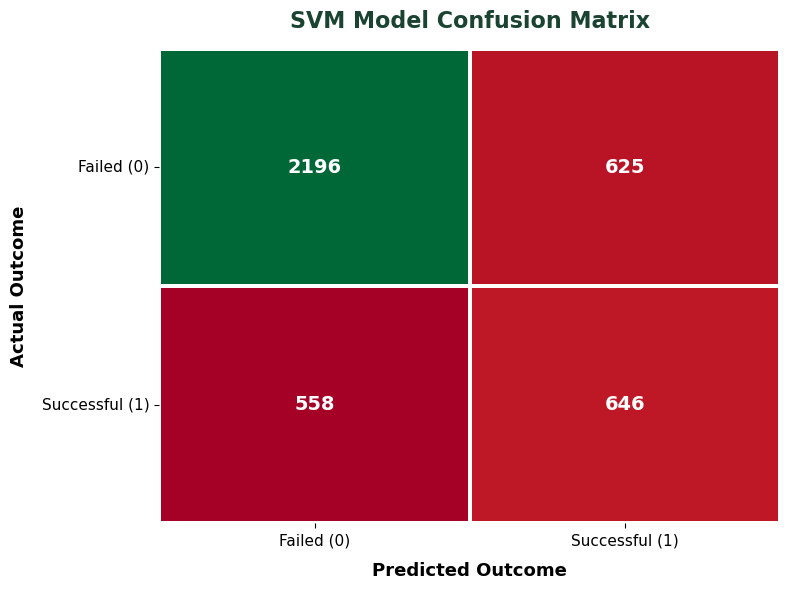

In [47]:
# Plot a Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='g', cmap='RdYlGn', cbar=False,
            xticklabels=['Failed (0)', 'Successful (1)'],
            yticklabels=['Failed (0)', 'Successful (1)'],
            annot_kws={"size": 14, "weight": "bold"},
            linewidths=1.5, linecolor='white')

plt.title('SVM Model Confusion Matrix', fontsize=16, fontweight='bold', pad=15, color='#1b4332')
plt.xlabel('Predicted Outcome', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Actual Outcome', fontsize=13, fontweight='bold', labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

## Visualizing Predictions: Confusion Matrix Analysis

The Confusion Matrix visually validates the trade-offs our model made to handle the severely imbalanced dataset. Here is the breakdown of the model's decision-making process:

*   **Top-Left (2196 - True Negatives):** The model successfully identified 2,196 failed campaigns. It correctly recognizes the dominant patterns of failure in the dataset.
*   **Bottom-Right (646 - True Positives):** This is the direct result of our `class_weight='balanced'` strategy. The model successfully identified **53.6%** of all truly successful projects (646 out of 1204). Predicting crowdfunding success *without* accessing post-launch data (like pledged amounts) is notoriously difficult, making this a solid baseline achievement.
*   **Top-Right (625 - False Positives):** The "Optimism" cost. By forcing the model to heavily weight the minority class, it became slightly more optimistic, incorrectly flagging 625 failed projects as potential successes. 
*   **Bottom-Left (558 - False Negatives):** The model missed 558 successful projects, classifying them as failures. These are likely projects that had weak initial parameters (e.g., poor categorical features or short durations) but succeeded due to external factors not captured in our data (like viral marketing or social media influence).

**Conclusion:**
Without the `balanced` class weight, the bottom-right quadrant would be significantly closer to zero, as the SVM would default to predicting "Failed" for almost everything to artificially inflate raw accuracy. This matrix proves that our pipeline successfully forced the algorithm to respect the minority class and capture meaningful patterns of success.

### Added model saving step and exported kickstarter_model.pkl

In [48]:
import joblib

joblib.dump(grid.best_estimator_, 'kickstarter_model.pkl')

print("Model saved successfully as 'kickstarter_model.pkl'")

Model saved successfully as 'kickstarter_model.pkl'


## Trying Random Forest Classifier

In [38]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

rf_pipeline = Pipeline(steps=[
    ("cleaning", cleaning_transformer),
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 20, 30],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('cleaning',
                                        FunctionTransformer(func=<function clean_data at 0x0000018C321C05E0>)),
                                       ('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['goal',
                                                                          'static_usd_rate',
                                                                          'name_len',
                                                                          'name_len_clean',
                                                                          'blurb_len',
                                                                          'blurb_len_cl...
                                                                          'deadline_month',
                                                                          'created_at_month',
                                                                          'launched_at_month'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 20, 30],
                         'model__max_features': ['sqrt'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [200, 300]},
             scoring='f1_macro', verbose=2)

In [39]:
# ================================
# Random Forest Evaluation
# ================================

best_rf_model = rf_grid.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest CV F1 Score:")
print(rf_grid.best_score_)

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nWeighted F1:")
print(f1_score(y_test, y_pred_rf, average="weighted"))

print("\nMacro F1:")
print(f1_score(y_test, y_pred_rf, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Best Parameters:
{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Best CV F1 Score:
0.7149181421559592

Test Accuracy:
0.7721739130434783

Weighted F1:
0.764723669842957

Macro F1:
0.7116529947097288

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      2821
           1       0.65      0.52      0.58      1204

    accuracy                           0.77      4025
   macro avg       0.73      0.70      0.71      4025
weighted avg       0.76      0.77      0.76      4025


Confusion Matrix:
[[2476  345]
 [ 572  632]]
